In [336]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import time
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from gensim.corpora import Dictionary
from gensim.models import TfidfModel, LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis.gensim_models
import ssl
import pickle
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")

df = pd.read_excel('colleges_final/sepehr_colleges_links.xlsx')
df.drop(columns=['UID', 'state', 'yearClosed', 'yearEstablished', 'index'], inplace=True)
df.rename(columns={'links': 'article'}, inplace=True)
df.fillna({'hed': 1}, inplace=True)
df = df.replace({'hed': {0: 'False', 1: 'True'}})
df

,name,article,hed
0,Alderson Broaddus University,https://www.highereddive.com/news/alderson-bro...,True
1,Alliance University (Formerly Nyack College),https://www.highereddive.com/news/alliance-uni...,True
2,Ancilla College,https://www.inkfreenews.com/2020/08/28/ancilla...,False
3,Becker College,https://apnews.com/general-news-f28092c26214a6...,False
4,Bloomfield College,https://www.highereddive.com/news/months-after...,True
...,...,...,...
60,Eastern Nazarene College,https://www.highereddive.com/news/eastern-naza...,True
61,Cox College,https://www.highereddive.com/news/cox-college-...,True
62,University of Wisconsin–Platteville Richland,https://www.highereddive.com/news/uw-plattevil...,True
63,Maryland University of Integrative Health,https://www.highereddive.com/news/notre-dame-o...,True


## Extracting

In [337]:
# def extract1(url):
#     try:
#         headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
#         response = requests.get(url, headers=headers, timeout=10)
#         response.raise_for_status()

#         soup = BeautifulSoup(response.text, 'html.parser')

#         article_div = soup.find('div', class_='large medium article-body')
#         if not article_div:
#             return "Error: Article body div not found"

#         paragraphs = article_div.find_all('p')
#         if not paragraphs:
#             return "Error: No paragraphs found in article body"

#         text = ' '.join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))
#         return text if text else "No content extracted"

#     except requests.RequestException as e:
#         print(f"Error downloading {url}: {e}")
#         return "Error: Failed to download"
#     except Exception as e:
#         print(f"Error parsing {url}: {e}")
#         return "Error: Failed to parse"

# def extract2(url):
#     try:
#         headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
#         response = requests.get(url, headers=headers, timeout=10)
#         response.raise_for_status()

#         soup = BeautifulSoup(response.text, 'html.parser')

#         for tag in soup.find_all(['header', 'footer', 'aside', 'nav', 'script', 'style']):
#             tag.decompose()

#         article_container = None
#         possible_selectors = [
#             ('article', None),
#             ('div', ['article', 'content', 'post', 'article-body', 'story', 'main-content', 'body-text']),
#             ('section', ['article', 'content', 'post'])
#         ]

#         for tag, class_names in possible_selectors:
#             if class_names:
#                 for class_name in class_names:
#                     container = soup.find(tag, class_=lambda x: x and class_name in x.lower())
#                     if container:
#                         article_container = container
#                         break
#             else:
#                 container = soup.find(tag)
#                 if container:
#                     article_container = container
#                     break
#             if article_container:
#                 break

#         if not article_container:
#             return "Error: No article container found"

#         paragraphs = article_container.find_all('p')
#         if not paragraphs:
#             return "Error: No paragraphs found in article container"

#         text = ' '.join(p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True))
#         return text if text else "No content extracted"

#     except requests.RequestException as e:
#         print(f"Error downloading {url}: {e}")
#         return "Error: Failed to download"
#     except Exception as e:
#         print(f"Error parsing {url}: {e}")
#         return "Error: Failed to parse"

# if 'content' not in df.columns:
#     df['content'] = ""

# for index, row in df.iterrows():
#     if row.get('hed', False):
#         url = row['article']
#         college = row['name']
#         print(f"Processing ({index}){college}...")
#         text = extract1(url)
#         df.at[index, 'content'] = text
#         time.sleep(1)

# print("Pausing...")
# time.sleep(5)

# for index, row in df.iterrows():
#     if not row.get('hed', False):
#         url = row['article']
#         college = row['name']
#         print(f"Processing ({index}){college}...")
#         text = extract2(url)
#         df.at[index, 'content'] = text
#         time.sleep(1)

In [338]:
# df

In [339]:
# error_rows = df[df['content'].str.startswith(("Error", "No content extracted"))]
# for index, row in error_rows.iterrows():
#     print(f"{row['name']}, {row['content']}")
# print(f"\nnum rows: {len(error_rows)}")

In [340]:
# becker_content = "WORCESTER, Mass. (AP) — Becker College in Massachusetts, citing a shaky financial situation made worse by the coronavirus pandemic, has announced that it is closing permanently at the end of the current academic year. The private Worcester school's trustees made the decision Sunday, the college posted on its website Monday. 'Particularly as a Becker alumna myself, this was an exceptionally painful decision for the board to come to, but one that followed many months of striving for a viable, sustainable, and responsible path to address the increasing financial pressures on our college,' trustees chair Christine Cassidy said in the statement. This year's graduation is scheduled for May, and the school will continue to provide academic support and transitional services to students through Aug. 31. Enrollment fell in 2018 and 2019, and, in response, the school took measures to ease the financial strain, including renegotiating contracts with vendors, selling some assets, consolidating departments, and reducing staff and pay, the statement said. The school had fewer than 1,700 undergraduate and graduate students enrolled, according to its fall 2020 institutional profile. The COVID-19 crisis made things worse through an 'unanticipated and significant drop in the number of students,' Becker said. 'This loss of revenue had a dramatic impact on the ability of the college to continue to maintain financial day-to-day college operations,' the statement said. Becker also looked at mergers that didn't pan out, Cassidy wrote. In conjunction with Becker's announcement, Clark University said Monday it is establishing the Becker School of Design & Technology to house Becker's renowned game design program. Many of the program's faculty and students are expected to transition to Clark, also in Worcester. Clark intends to operate the school in facilities at Becker's campus for at least a year. Becker traces its roots to 1784 when Leicester Academy was founded. Becker's Business College was founded in 1887 and the two institutions merged in 1977, according to the school's website."
# cabrini_content = "RADNOR, Pa. (AP) — Cabrini University has announced that it will close at the end of the 2023-24 school year, with Villanova University assuming ownership of the nearby land in the Philadelphia suburbs where the fellow Roman Catholic university is located. Cabrini's interim president Helen Drinan called it 'difficult news' in a video statement Friday, saying the 66-year-old institution would graduate 'it's final class' in 2024. 'Faced with significant financial challenges, exacerbated by declining enrollment and the COVID-19 pandemic,' Drinan said, officials 'determined that there is no credible path forward that will allow Cabrini University to continue operating beyond June 2024.' Cabrini had over the years tried to boost enrollment and revenue in a number of ways such as new programs, online options and working to attract international students, and had also tried to cut expenses as much as possible, but none of that was enough to overcome the school's 'long-term structural operating deficit,' she said. Both schools emphasized that Cabrini's name will be retained, with Villanova vowing to preserve the university's legacy 'both in name and in the continuation of some of the institution's most impactful work in education, nursing, service, immigration, and the advancement of women.'"
# judson_content = "The Baptist women's college had only 12 new students committed to attend in the fall. After teetering on the edge of closure for months, Judson College's Board of Trustees voted Thursday to close the Baptist women's college in July. The college, located in Marion, Ala., had been in poor financial shape for years, but its financial outlook worsened in recent months even though the college raised more than \$2.53 million this academic year. Enrollment, which had been declining for more than a decade, was dismal this spring, with only 145 students enrolled. Only 80 students were expected to return for the upcoming academic year, and only a dozen new students had committed to attend Judson in the fall. The board voted in April to approve a budget for the 2021-22 academic year, betting on new donor leads that could result in significant gifts to the college. Those gifts never materialized, according to a college press release. Two days before Thursday's board meeting, one of Judson's creditors called a note on a loan that was due and was not renewed."
# mcmurray_content = "The Board of Trustees of MacMurray College announced March 27 it will close at the end of the spring semester in May 2020, ending a 174-year history in higher education. Charles O'Connell, chair of the Board of Trustees, said the Board voted unanimously to close after extensive analysis and consideration, reaching the conclusion that the school 'had no viable financial path forward,' with declining enrollments, rising competitive costs and a small endowment. He noted that alumni had been generous in a recent fundraising drive, but that it was not sufficient to reverse trends. The Board thanked MacMurray College President Dr. Beverly Rodgers for her leadership since being appointed to the job in 2019. 'Our students remain our top priority,' Dr. Rodgers said. 'Faculty and staff have gone the extra mile in transferring all our classes to online and remote learning formats — practically overnight.' She said that MacMurray has signed transfer agreements for its current students with seven area colleges. 'We will assist all students in their transfer needs, helping them ensure they are able to complete their degrees. We will also support our faculty and staff in their transitions to other positions.' The coronavirus pandemic and resulting economic disruption were recent factors that complicated MacMurray's financial condition, but they are not the principal reasons for the Board's decision to close, according to O'Connell. The college currently has 527 full-time students and 101 faculty and staff. Due to the COVID-19 pandemic, students already have moved off campus and are taking classes online. The college has not decided whether or not to hold its commencement ceremony as scheduled on May 9. Students not eligible for graduation in May will be referred to a partner institution to complete their degree. The college has negotiated transfer agreements for its students at Blackburn College, Eureka College, Greenville University, Illinois College, McKendree University, Millikin University and Monmouth College. The college was founded in 1846 by Methodist clergy as the Illinois Conference Female Academy. It is one of the oldest colleges originally for women in the United States and one of the oldest liberal arts colleges in Illinois. The name was changed in 1899 to Illinois Woman's College. In 1913, the college was granted accreditation. The name was changed again in 1930 to MacMurray College for Women. Foreseeing the coming baby boom, the college's board of trustees established MacMurray College for Men in 1955. The men's and women's colleges merged in 1969. O'Connell said the pandemic and subsequent economic disruption were factors that complicated the college's recent financial position but were not the main reasons for the closure. The status of the college's 60-acre campus, located on the east side of Jacksonville, was not immediately clear. The archive collection of the Illinois Great Rivers Conference of The United Methodist Church is located on campus at Pfeiffer Library. Conference officials will be exploring potential sites to relocate the collection in the near future."
# marlboro_content = "Marlboro College has released documents pertaining to the Board of Trustees' decision to seek a merger with Emerson College in Boston. The document release was in response to a 'challenge' issued during a community meeting Dec. 14 on the campus. In that challenge, Will Wootton, class of 1972, an administrator at Marlboro for nearly two decades between 1983 and 2002 and president of Sterling College in Craftsbury between 2006 and 2012, asked that he and others be allowed four days to review the information. '(W)ithin seven days we will deliver to the board a report showing how the college can welcome a new class in September, and begin building for the future,' said Adrian Segar, who taught at Marlboro College for 10 years, during the Dec. 14 meeting. If the group, in its own analysis, reaches the same conclusion as the board, Segar said, it will not deliver the report and will instead acknowledge, as the Board of Trustees stated, 'There is no credible evidence to suggest that Marlboro can make it on its own.' The information released on the college's website includes financial statements from 2015 through 2019 and tax returns from 2013 to 2017. Other information published on the website includes census data pertaining to U.S. birth rates, which provides information on the number of college-aged students in any given year, demonstrating sharp declines in the number of potential students in Marlboro's demographic. The website also includes a link to the Integrated Postsecondary Education Data System, a federal system that provides information including data on enrollment, admissions, human resources, finances and net tuition revenue. In addition to that information, the college has posted a link to a letter issued on Thursday by the New England Commission of Higher Education, which accredits colleges and universities in New England. The letter notes the commission's formal 'Notice of Concern' that the college is in danger of not meeting its standards. While this letter doesn't necessarily revoke Marlboro's accreditation, it serves as a reminder that that is a possibility if remedies are not taken. 'Marlboro College continues to face serious challenges with respect to finance and enrollment, as evidenced by the College's inability to substantially increase net tuition revenue and to balance its budget,' the letter reads. Over the past three years, the letter states, student revenue has decreased from \$3.6 million to \$1.7 million. And although the college has an endowment of \$35.7 million, drawing 6.5 percent from the endowment in 2019 and 18 percent in 2020 to keep the college operating is 'unsustainable.' 'The institution's (tuition) discount rate of 67 percent, while lower than the previous year's rate of 81 percent, is also unsustainable and, as candidly noted ... the high discount rate has not been effective in attracting a sufficient number of new students to the College,' states the NECHE letter. The letter noted that a merger with Emerson College is an acceptable remedy to the situation at Marlboro. 'We also concur with the College that 'a successful merger is the only way to address the financial and enrollment concerns' the Commission has identified,' the letter states. 'We are therefore, gratified to learn that Marlboro and Emerson College have formally agreed to a Term Sheet that serves as the foundation for a full merger agreement that the governing boards of both institutions are expected to approve at their respective meetings in Spring 2020.' 'The trustees believe that acting now, before the endowment is exhausted and options become extremely limited, is the most appropriate way to protect the interests of the students, faculty and Marlboro community,' stated Marlboro College Board of Trustees in a letter issued two days after the Dec. 14 meeting. In the event the proposal between the two colleges is not successful, Marlboro College has developed a plan for what is known as 'an ethical closure.' 'The institution is considering two scenarios: a two-year teach out leading to closure at the end of (fiscal year) 2021 and a three-year teach out with closure at the end of FY2022,' notes the NECHE letter. 'Marlboro has also had 'preliminary conversations' with other colleges that would be able to accommodate students unable to complete their educational programs through the proposed teach out. ... (F)ailure on the part of the College to begin teaching out its students in the event the merger with Emerson does not transpire, will lead the Commission to immediately consider stronger public action.' What that public action might be is not mentioned in the letter. In the Board of Trustees letter published following the Dec. 14 meeting, the board noted that a severance package for all staff and administrators who will lose their jobs had been approved. The details of that severance package are not publicly available."
# pinemanor_content = "At its meeting April 24, 2020, the New England Commission of Higher Education (NECHE) voted to continue the March 2020 Notation with respect to Pine Manor College. The Notation indicates the Commission's finding that the College's accreditation may be in jeopardy if current financial conditions continue or worsen with respect to the Commission's standard on Institutional Resources. In continuing the Notation, the Commission took favorable note of the College's transparency with students, prospective students, and the College community and of the institution's commitment to making a decision no later than June 30 about the coming academic year. The Commission has asked Pine Manor College to update Commission staff on any development, positive or negative, that impacts the ability of the College to meet the Commission's Standards for Accreditation. The Commission monitors institutions issued a Notation, and will require a focused evaluation within two years to assess the institution's success in addressing the identified concerns. The Commission will continue to work closely with the College as it works to stabilize its resources and looks after the well-being of its students."
# woodbury_content = "The San Diego outpost of the Woodbury School of Architecture will close permanently at the end of this semester. Why it matters: Faculty and alumni built notable projects and influenced development across urban San Diego over the school's 26-year run. Driving the news: Los Angeles-based Woodbury University this year announced a merger with the University of Redlands that includes shutting down the San Diego campus that opened in 1998. Catherine Herbst, chair of the Barrio Logan school, said the university started winding down operations three years ago, letting students and faculty transfer to the LA campus in preparation for this spring's formal end, once the last 11 students finish. By the numbers: Since its first class graduated in 2001, the school has turned out nearly 500 students from its bachelor's of architecture program. It issued 170 graduate degrees and minted 74 state-licensed architects. The intrigue: Woodbury was especially influential because of its master's in real estate development (MRED) program, which gained notoriety by creating a model that taught architects to pursue their own projects rather than work for others. Typically, developers make decisions about how a project should look and feel based on financial and zoning constraints, and then hire architects to execute those needs. Alumni and faculty from the MRED program instead are in charge of the entire project, and their architectural decision making dictates the end result. What they're saying: 'The program was a critique of the way we build buildings in the United States,' said Andrew Malick, an MRED graduate who has become a prolific developer around the region. 'Our critique was, when an architect empowered in the business of development makes decisions, better buildings and better lifestyles are the result,' he said. Between the lines: Buildings from Woodbury-affiliated architects are linked by 'an approach, not an aesthetic,' said Tyler Hanson, a graduate and professor who has built projects in Golden Hill, North Park and Azalea Park. Woodbury architect-developers pursued small or odd lots in vibrant neighborhoods, while institutional developers chased simple, big projects downtown or on the outskirts of the city. They mastered zoning laws to maximize what they could build without triggering community hearings or approvals. '(Faculty member Ted Smith) calls it civil disobedience — I just call it being smart,' Herbst said. 'Navigating zoning and procedural democracy is something we all get really good at.' The other side: The freedom Woodbury architects celebrate has also riled residents, especially over the lack of parking for many projects. The big picture: For a decade, city leaders have slashed parking mandates, increased allowed housing density and removed development restrictions — all part of Woodbury's legacy, Malick says. 'The shadow of the MRED program is a re-envisioning of how we develop infill neighborhoods,' he said. Yes, but: Those reforms — especially Complete Communities, which dramatically slashed development restrictions — eventually enticed institutional players into those neighborhoods, diminishing small developers' competitive edge. What's next: Relaxed rules on building multiunit projects on single-family lots are creating new advantages for architects and developers, Hanson said."
# bhcarroll_content = "To 'eliminate redundancy in accreditation,' B.H. Carroll has withdrawn from its membership under the Commission on Accreditation of the Association for Biblical Higher Education in preparation for its merger with East Texas Baptist University. B.H. Carroll remains accredited by the Association for Theological Schools, and it will be accredited as a seminary within ETBU, pending review and approval of its merger with ETBU by the Southern Association of Colleges and Schools Commission on Colleges. 'We chose to withdraw to eliminate institutional redundancy in accreditation,' said Greg Tomlin, professor of Christian heritage and director of the Ph.D. program. 'After we achieved ATS accreditation in 2017, we no longer needed ABHE accreditation but maintained it to strengthen ties with other evangelically minded schools.' However, as an ATS-accredited seminary within a SACS-accredited university, B.H. Carroll decided 'it was time' to withdraw voluntarily from ABHE's accreditation commission. 'It saves us time, institutional resources and money,' Tomlin explained. In a Jan. 3 letter to ABHE, B.H. Carroll President Gene Wilkes said the association has been 'a valued partner in our shared mission of biblical theological education since 2012.' ABHE was the first group to accredit B.H. Carroll after examining the quality of its programs and faculty, as well as the unique nature of its model, using online instruction to provide theological education to students where they live and work. B.H. Carroll will always be grateful and remain committed to helping ABHE maintain its role in supporting biblical higher education, Wilkes said. 'God is doing great things through ABHE, and you have my personal support and prayers as we move into God's future for us all,' Wilkes wrote to the group's commissioners. ETBU administrators plan to explore affiliate membership with the association after the merger is complete to maintain the seminary's ties with ABHE. 'Our notification was a procedural requirement to comply with ABHE standards for accredited member institutions, but withdrawal was not required because of the merger,' Tomlin said. Withdrawal from ABHE's accreditation commission has no effect on students who have received a degree from B.H. Carroll, he noted. 'Their past degrees were and remain accredited,' he said. B.H. Carroll will continue to offer certificate programs for students who want graduate-level instruction but who are not seeking a degree, he added."

# x = {
#     'Becker College': becker_content,
#     'Cabrini University': cabrini_content,
#     'Judson College': judson_content,
#     'MacMurray College': mcmurray_content,
#     'Marlboro College': marlboro_content,
#     'Pine Manor College': pinemanor_content,
#     'Woodbury University': woodbury_content,
#     'B. H. Carroll Theological Seminary': bhcarroll_content,
# }

# for college, content in x.items():
#     df.loc[df['name'] == college, 'content'] = content

In [341]:
# error_rows = df[df['content'].str.startswith(("Error", "No content extracted"))]
# for index, row in error_rows.iterrows():
#     print(f"{row['name']}, {row['content']}")
# print(f"\nnum rows: {len(error_rows)}")

## Processing

In [342]:
df = pd.read_excel('article_content.xlsx')
df.drop(columns=['hed', 'article'], inplace=True)
df

,name,content
0,Alderson Broaddus University,"Alderson Broaddus University, a financially fr..."
1,Alliance University (Formerly Nyack College),"In March, MSCHE raised concerns over Alliance'..."
2,Ancilla College,Ancilla College and Marian University jointly ...
3,Becker College,"Becker College in Massachusetts, citing a shak..."
4,Bloomfield College,"Bloomfield is unique, calling itself the only ..."
...,...,...
60,Eastern Nazarene College,"In its closure announcement, Eastern Nazarene ..."
61,Cox College,"Cox College’s history stretches back to 1907, ..."
62,University of Wisconsin–Platteville Richland,The University of Wisconsin Platteville will e...
63,Maryland University of Integrative Health,Notre Dame of Maryland offers advanced degrees...


In [343]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

lemmatizer = WordNetLemmatizer()
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sepehrakbari/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sepehrakbari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sepehrakbari/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/sepehrakbari/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [344]:
college_names = df['name']
college_df = college_names.str.replace(r'\b(College|University|School|Campus)\b', '', regex=True).str.strip()
location_names = ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida",
                "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana",
                "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
                "Montana", "Nebraska", "Nevada", "New", "Hampshire", "Jersey", "Mexico", "York",
                "Carolina", "North", "Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania",
                "Rhode Island", "South Carolina", "South", "Dakota", "Tennessee", "Texas",
                "Utah", "Vermont", "Virginia", "Washington", "West", 'ann', 'arbor', 'boston', 'brooklyn', 'chicago', 'dallas',
                'denver', 'detroit', 'houston', 'las', 'vegas', 'los', 'angeles', 'miami', 'minneapolis',
                'new', 'orleans', 'new', 'york', 'philadelphia', 'phoenix', 'portland', 'san', 'antonio',
                'san', 'diego', 'san', 'francisco', 'seattle', 'washington', 'dc', 'atlanta',
                "Wisconsin", "Wyoming", "District", "Columbia", "Puerto", "Rico", "Indianapolis", "Chicago", "Los", "Angeles", "City", "Staten", "Island",
                'waukesha', 'milwaukee', 'bloomfield', 'uwm', 'redlands', 'stritch', 'uwplatteville', 'uwmadison',
                'uwoshkosh', 'uwgreenbay', 'uwlacrosse', 'uwstevenspoint', 'uwsuperior', 'uwwhitewater', 'southern', 'northern', 'central', 'eastern', 'western']
location_df = pd.DataFrame(location_names, columns=['name'])
time_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 
              'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
              'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December',
              'AM', 'PM', 'morning', 'afternoon', 'evening', 'night',
              'today', 'tomorrow', 'yesterday', 'now', 'soon', 'later', 'week', 'month', 'year',
              'weekend', 'holiday', 'vacation', 'break', 'semester', 'quarter', 'session', 'class', 'course',
              'schedule', 'timetable', 'appointment', 'meeting', 'event', 'deadline', 'due date']
time_df = pd.DataFrame(time_names, columns=['name'])
fillers = ['the', 'a', 'an', 'and', 'or', 'but', 'if', 'then', 'that', 'which', 'who', 'whom',
           'whose', 'what', 'where', 'when', 'why', 'how', 'so', 'such', 'very', 'too',
           'just', 'only', 'even', 'also', 'still', 'yet', 'already', 'still', 'again',
           'back', 'forth', 'here', 'there', 'everywhere', 'anywhere', 'nowhere', 'somewhere',
           'anyone', 'everyone', 'someone', 'no one', 'nothing', 'everything', 'something',
           'anything', 'everything', 'something', 'nothing', 'nobody', 'everybody', 'somebody',
           'anybody', 'everybody', 'somebody', 'nobody', 'each', 'every', 'all', 'both', 'there',
           'though', 'although', 'even though', 'despite', 'in spite of', 'because', 'since',
           'either', 'neither', 'whether', 'while', 'as', 'like', 'such as', 'for example',
           'good', 'bad', 'great', 'awesome', 'fantastic', 'terrible', 'horrible',
           'amazing', 'wonderful', 'excellent', 'poor', 'mediocre',
           'interesting', 'would', 'will', 'shall', 'can', 'could', 'may', 'might',
           'must', 'should', 'ought to', 'need to', 'have to',
           'want to', 'like to', 'love to', 'hate to', 'prefer', 'known', 'dozen', 'founded', 'want', 'closing', 'leader',
           'institute', 'college', 'university', 'school', 'campus', 'program', 'department',
           'faculty', 'student', 'staff', 'administration', 'board', 'trustees', 'president',
           'chancellor', 'dean', 'director', 'office', 'center', 'institute', 'program', 'major',
           'minor', 'course', 'class', 'degree', 'diploma', 'certificate', 'transcript', 'going', 'system']
fillers_df = pd.DataFrame(fillers, columns=['name'])

stop_words = set(stopwords.words('english'))
custom_stop_words = {'university', 'read', 'subscribe', 'click', 
                        'newsletter', 'email', 'reported', 'said',
                        'says', 'report', 'according', 'college',
                        'island', 'staten', 'state', 'evans', 'notre', 'dame', 'martin', 'uwoshkosh',
                        'berg', 'louis', 'school', 'campus', 'college', 'university', 'robert', 'johnson', 'see', 
                        'increasing', 'decreasing', 'declining', 'rise', 'fall', 'growth', 'decline', 'trend',
                        'vice', 'hope', 'located', 'location', 'john', 'option', 'one', 'detail', 'joint'}
custom_stop_words.update(college_df.str.lower().tolist())
custom_stop_words.update(location_df['name'].str.lower().tolist())
custom_stop_words.update(time_df['name'].str.lower().tolist())
custom_stop_words.update(fillers_df['name'].str.lower().tolist())
stop_words.update(custom_stop_words)

In [345]:
def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return []
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    tokens = [token for token in tokens if token not in stop_words]
    tokens = [token for token in tokens if len(token) > 2 and len(token) < 20]
    tokens = [token for token in tokens if not token.isdigit()]
    tokens = [token for token in tokens if token.isalpha()]

    return tokens

dfc = df.copy()
dfc['tokens'] = dfc['content'].apply(preprocess_text)
dfc

,name,content,tokens
0,Alderson Broaddus University,"Alderson Broaddus University, a financially fr...","[alderson, broaddus, financially, fragile, bap..."
1,Alliance University (Formerly Nyack College),"In March, MSCHE raised concerns over Alliance'...","[msche, raised, concern, alliance, financial, ..."
2,Ancilla College,Ancilla College and Marian University jointly ...,"[marian, jointly, announced, collaboration, mi..."
3,Becker College,"Becker College in Massachusetts, citing a shak...","[citing, shaky, financial, situation, made, wo..."
4,Bloomfield College,"Bloomfield is unique, calling itself the only ...","[unique, calling, fouryear, predominantly, bla..."
...,...,...,...
60,Eastern Nazarene College,"In its closure announcement, Eastern Nazarene ...","[closure, announcement, nazarene, referenced, ..."
61,Cox College,"Cox College’s history stretches back to 1907, ...","[history, stretch, established, burge, deacone..."
62,University of Wisconsin–Platteville Richland,The University of Wisconsin Platteville will e...,"[platteville, eliminate, position, workforce, ..."
63,Maryland University of Integrative Health,Notre Dame of Maryland offers advanced degrees...,"[offer, advanced, nursing, pharmacy, occupatio..."


In [346]:
dictionary = Dictionary(dfc['tokens'])
dictionary.filter_extremes(no_below=7, no_above=0.9)
corpus = [dictionary.doc2bow(text) for text in dfc['tokens']]

In [347]:
dfc.to_csv("processed_article_content.csv", index=False)
dictionary.save("article_dictionary.gensim")

tfidf = TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

with open("corpus_tfidf.pkl", "wb") as f:
    pickle.dump(corpus_tfidf, f)

## LDA

In [348]:
df = pd.read_csv("processed_article_content.csv")
dictionary = Dictionary.load("article_dictionary.gensim")
with open("corpus_tfidf.pkl", "rb") as f:
    corpus_tfidf = pickle.load(f)

rs = 42

df

,name,content,tokens
0,Alderson Broaddus University,"Alderson Broaddus University, a financially fr...","['alderson', 'broaddus', 'financially', 'fragi..."
1,Alliance University (Formerly Nyack College),"In March, MSCHE raised concerns over Alliance'...","['msche', 'raised', 'concern', 'alliance', 'fi..."
2,Ancilla College,Ancilla College and Marian University jointly ...,"['marian', 'jointly', 'announced', 'collaborat..."
3,Becker College,"Becker College in Massachusetts, citing a shak...","['citing', 'shaky', 'financial', 'situation', ..."
4,Bloomfield College,"Bloomfield is unique, calling itself the only ...","['unique', 'calling', 'fouryear', 'predominant..."
...,...,...,...
60,Eastern Nazarene College,"In its closure announcement, Eastern Nazarene ...","['closure', 'announcement', 'nazarene', 'refer..."
61,Cox College,"Cox College’s history stretches back to 1907, ...","['history', 'stretch', 'established', 'burge',..."
62,University of Wisconsin–Platteville Richland,The University of Wisconsin Platteville will e...,"['platteville', 'eliminate', 'position', 'work..."
63,Maryland University of Integrative Health,Notre Dame of Maryland offers advanced degrees...,"['offer', 'advanced', 'nursing', 'pharmacy', '..."


In [349]:
num_topics = 4
lda_model = LdaModel(corpus=corpus_tfidf, id2word=dictionary, num_topics=num_topics, passes=15, random_state=rs)
topics = lda_model.print_topics(num_words=10)
# for topic in topics:
#     print(f"Topic {topic[0]}: {topic[1]}")
for topic in topics:
    print(topic)

(0, '0.009*"commission" + 0.009*"accreditation" + 0.007*"association" + 0.006*"condition" + 0.006*"point" + 0.005*"saying" + 0.005*"planned" + 0.005*"standard" + 0.005*"dollar" + 0.005*"recently"')
(1, '0.007*"saint" + 0.006*"institution" + 0.006*"merger" + 0.006*"million" + 0.006*"county" + 0.005*"christian" + 0.005*"trustee" + 0.005*"pandemic" + 0.005*"education" + 0.005*"tuition"')
(2, '0.009*"early" + 0.008*"offer" + 0.008*"several" + 0.007*"need" + 0.006*"time" + 0.005*"education" + 0.004*"result" + 0.004*"committed" + 0.003*"health" + 0.003*"healthcare"')
(3, '0.004*"population" + 0.004*"increase" + 0.004*"acquisition" + 0.004*"tuition" + 0.003*"merger" + 0.003*"change" + 0.003*"online" + 0.003*"transition" + 0.003*"economic" + 0.003*"trustee"')


In [358]:
topics_df = pd.DataFrame(topics, columns=['Topic ID', 'Words'])
topics_df['Words'] = topics_df['Words'].apply(
    lambda x: dict([
        (word_part.split('*')[1].strip('"'), float(word_part.split('*')[0]))
        for word_part in x.split(' +')
    ])
)
topics_df

,Topic ID,Words
0,0,"{'commission': 0.009, 'accreditation': 0.009, ..."
1,1,"{'saint': 0.007, 'institution': 0.006, 'merger..."
2,2,"{'early': 0.009, 'offer': 0.008, 'several': 0...."
3,3,"{'population': 0.004, 'increase': 0.004, 'acqu..."


In [359]:
for index, row in topics_df.iterrows():
    print(f"Topic {row['Topic ID']}:")
    for word, freq in row['Words'].items():
        print(f"  {word}: {freq}")
    print()

Topic 0:
  commission: 0.009
  accreditation: 0.009
  association: 0.007
  condition: 0.006
  point: 0.006
  saying: 0.005
  planned: 0.005
  standard: 0.005
  dollar: 0.005
  recently: 0.005

Topic 1:
  saint: 0.007
  institution: 0.006
  merger: 0.006
  million: 0.006
  county: 0.006
  christian: 0.005
  trustee: 0.005
  pandemic: 0.005
  education: 0.005
  tuition: 0.005

Topic 2:
  early: 0.009
  offer: 0.008
  several: 0.008
  need: 0.007
  time: 0.006
  education: 0.005
  result: 0.004
  committed: 0.004
  health: 0.003
  healthcare: 0.003

Topic 3:
  population: 0.004
  increase: 0.004
  acquisition: 0.004
  tuition: 0.004
  merger: 0.003
  change: 0.003
  online: 0.003
  transition: 0.003
  economic: 0.003
  trustee: 0.003



In [360]:
article_topics = []
for i, doc_bow in enumerate(corpus_tfidf):
    topic_dist = lda_model.get_document_topics(doc_bow, minimum_probability=0)
    top_topic = sorted(topic_dist, key=lambda x: x[1], reverse=True)[0]
    topic_id, prob = top_topic
    topic_words = ', '.join(word for word, _ in lda_model.show_topic(topic_id, topn=5))
    article_topics.append({'name': df['name'][i], 'Top Topic': topic_id, 'Probability': prob, 'Keywords': topic_words})

results_df = pd.DataFrame(article_topics)
results_df

,name,Top Topic,Probability,Keywords
0,Alderson Broaddus University,1,0.918103,"saint, institution, merger, million, county"
1,Alliance University (Formerly Nyack College),1,0.882523,"saint, institution, merger, million, county"
2,Ancilla College,1,0.909903,"saint, institution, merger, million, county"
3,Becker College,1,0.907043,"saint, institution, merger, million, county"
4,Bloomfield College,1,0.917277,"saint, institution, merger, million, county"
...,...,...,...,...
60,Eastern Nazarene College,1,0.912962,"saint, institution, merger, million, county"
61,Cox College,1,0.910991,"saint, institution, merger, million, county"
62,University of Wisconsin–Platteville Richland,1,0.909389,"saint, institution, merger, million, county"
63,Maryland University of Integrative Health,1,0.891966,"saint, institution, merger, million, county"


In [361]:
topic_counts = results_df['Top Topic'].value_counts(normalize=True) * 100
print("Topic Prevalence (%):")
for topic_id, perc in topic_counts.items():
    words = ', '.join(word for word, _ in lda_model.show_topic(topic_id, topn=5))
    print(f"Topic {topic_id} ({perc:.2f}%): {words}")

Topic Prevalence (%):
Topic 1 (98.46%): saint, institution, merger, million, county
Topic 2 (1.54%): early, offer, several, need, time


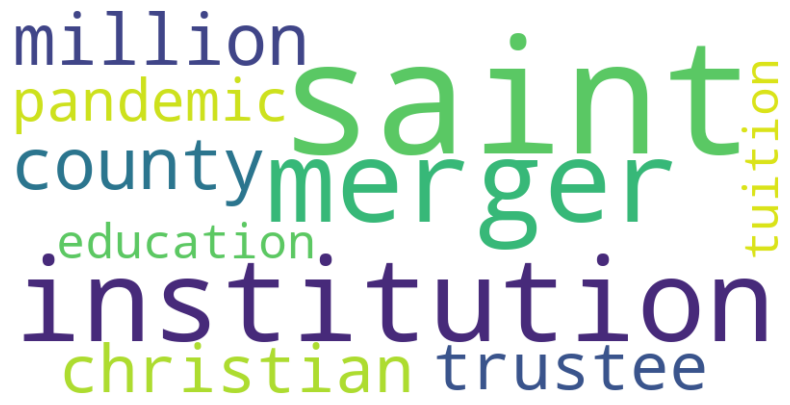

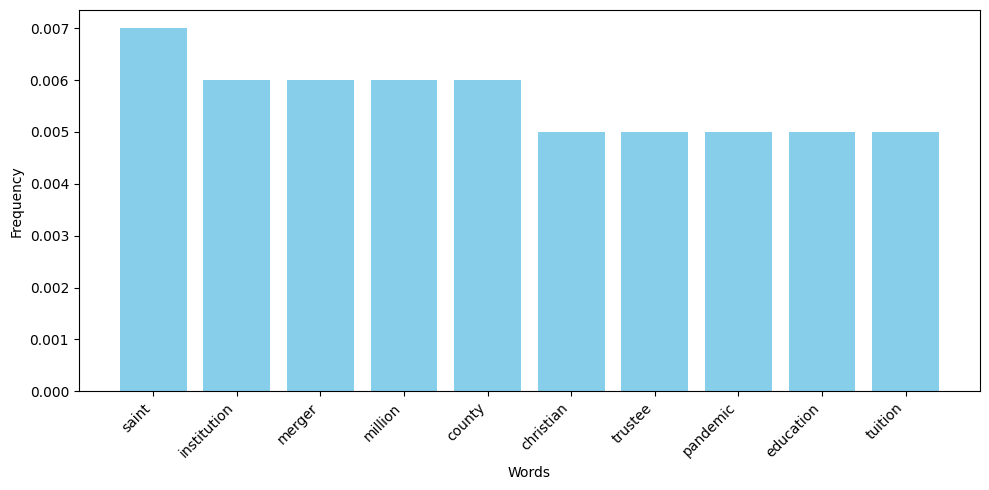

In [391]:
def visualize_dictionary(word_frequencies_dict):
    """
    Visualize a dictionary using word clouds and bar charts.

    Parameter:
    - word_dict: Dictionary where keys are frequencies and values are words.
    """
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_frequencies_dict)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.grid(False)
    plt.show()

    # --- Bar Chart Visualization ---
    # Sort words by frequency for better readability in the bar chart
    sorted_words = sorted(word_frequencies_dict.items(), key=lambda item: item[1], reverse=True)
    words = [item[0] for item in sorted_words]
    frequencies = [item[1] for item in sorted_words]

    plt.figure(figsize=(10, 5))
    plt.bar(words, frequencies, color='skyblue')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right') # Rotate labels and align them for better readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

i = 1 # For example, to visualize the first topic
topic_id_to_visualize = topics_df.iloc[i]['Topic ID']
word_dictionary_for_topic = topics_df.iloc[i]['Words']

visualize_dictionary(word_dictionary_for_topic)

In [354]:
# coherence_model = CoherenceModel(model=lda_model, texts=df['tokens'], dictionary=dictionary, coherence='c_v')
# coherence_score = coherence_model.get_coherence()
# print(f"Coherence Score: {coherence_score}")